In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [4]:
df.shape

(514547, 9)

In [5]:
df = df[df["Quantity"] > 0]
df.shape[0]

504731

In [6]:
df["Quantity"].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [7]:
df = df.sort_values(by = "Quantity", ascending = False)
df["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]) 

0.50      3.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

<Axes: xlabel='Quantity', ylabel='Count'>

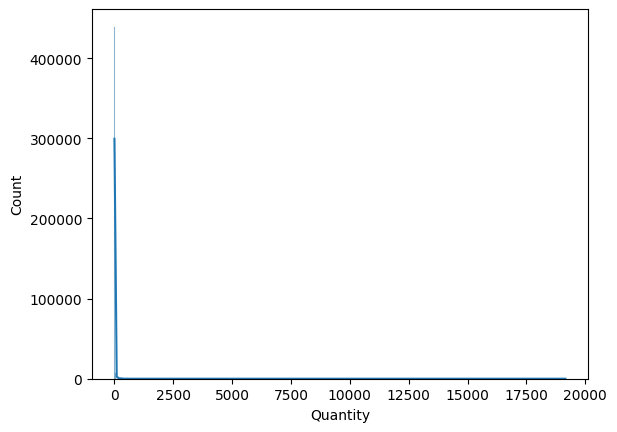

In [8]:
# plot histogram of quantity
sns.histplot(data=df, x="Quantity", kde=True)

## Separate retail from massive wholesale

I am using a hybrid binning approach with pd.cut()

In [9]:
# Splitting at 1,000 isolates the predictable wholesale from unpredictable bulk
bin_edges = [0, 1, 3, 12, 32, 120, 1000, np.inf]
bin_labels = [
    'Micro',            # 1
    'Standard',         # 2-3
    'Heavy-Retail',     # 4-12
    'Commercial',       # 13-32
    'High-Vol-Comm',    # 33-120
    'Core-Wholesale',   # 121-1000  -> Predictable modeling range
    'Mega-Bulk-Tail'    # 1001-19152 -> Handle separately / rules-based
]

df['Segment'] = pd.cut(df['Quantity'], bins=bin_edges, labels=bin_labels)


In [10]:
df["Segment"].value_counts()

Segment
Heavy-Retail      185220
Micro             140796
Standard          112482
Commercial         42027
High-Vol-Comm      19750
Core-Wholesale      4253
Mega-Bulk-Tail       203
Name: count, dtype: int64

In [11]:
# save to csv for reuse
df.to_parquet("../data/processed/transactions_with_segments.parquet", index=False)

In [12]:
wholesale_df = df[df['Segment'] == "Core-Wholesale"]
print(wholesale_df.shape[0])
print(wholesale_df["Quantity"].describe())

4253
count    4253.000000
mean      265.458735
std       157.087491
min       121.000000
25%       144.000000
50%       200.000000
75%       288.000000
max      1000.000000
Name: Quantity, dtype: float64


In [13]:
# Convert InvoiceDate to datetime and set it as index for time-series modeling
wholesale_df['InvoiceDate'] = pd.to_datetime(wholesale_df['InvoiceDate'])

In [14]:
df = wholesale_df.copy()

In [15]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 14:05:00
2009-12-01 10:46:00


## Feature Engineering

### Aggregate Data to Daily Demand

In [16]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [17]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,16237,180,0.21
1,2009-12-01,17003,144,0.21
2,2009-12-01,17164D,288,0.37
3,2009-12-01,17165B,288,0.85
4,2009-12-01,21017,192,0.72


In [18]:
daily_demand_df.shape

(4043, 4)

I will use the functions I have already written in features subfolder

In [19]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku_features import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [20]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [21]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [22]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [23]:

demand_features = build_demand_features(daily_demand_df)

In [24]:
demand_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_avg_price,sku_cv,target
0,2009-12-01,16237,180,0.21,1.063291,1,1,49,12,4,...,NaN,NaN,NaN,NaN,202.500000,180.0,45.000000,0.197500,0.222222,5.198497
1,2009-12-01,17003,144,0.21,1.172281,1,1,49,12,4,...,NaN,NaN,NaN,NaN,537.034483,720.0,269.992921,0.179138,0.502748,4.976734
2,2009-12-01,17164D,288,0.37,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,240.000000,288.0,83.138439,0.370000,0.346410,5.666427
3,2009-12-01,17165B,288,0.85,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,288.000000,288.0,NaN,0.850000,NaN,5.666427
4,2009-12-01,21017,192,0.72,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,192.000000,192.0,NaN,0.720000,NaN,5.262690


In [25]:
demand_features.shape

(4043, 40)

In [26]:
demand_features['StockCode'].nunique()

1200

In [27]:
demand_features['InvoiceDate'].max()

Timestamp('2010-12-09 00:00:00')

## Build and Train LIGHTGBM Model

In [28]:
# timebased train-valid split
def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    demand_features,
    date_col='InvoiceDate',
    split_date='2010-10-01'
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (3085, 40)
Valid shape: (958, 40)


In [29]:
import joblib
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [30]:
X_train = train_df.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_df[TARGET_COL]

X_test = valid_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = valid_df[TARGET_COL]   

In [31]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_avg_price', 'sku_cv'],
      dtype='str')

In [32]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [33]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001562 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 3085, number of used features: 33
[LightGBM] [Info] Start training from score 281.758833
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[57]	valid_0's rmse: 139.683


In [34]:
# make predictions
predictions = model.predict(X_test)

## Evaluation

In [35]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 81.10131809879807,
 'RMSE': 139.68321387998043,
 'wmape_sklearn': np.float64(0.2990917455389327),
 'WMAPE': np.float64(0.29909174553893275)}

## Feature Importance

Plot the feature importance to see what drove these predictions

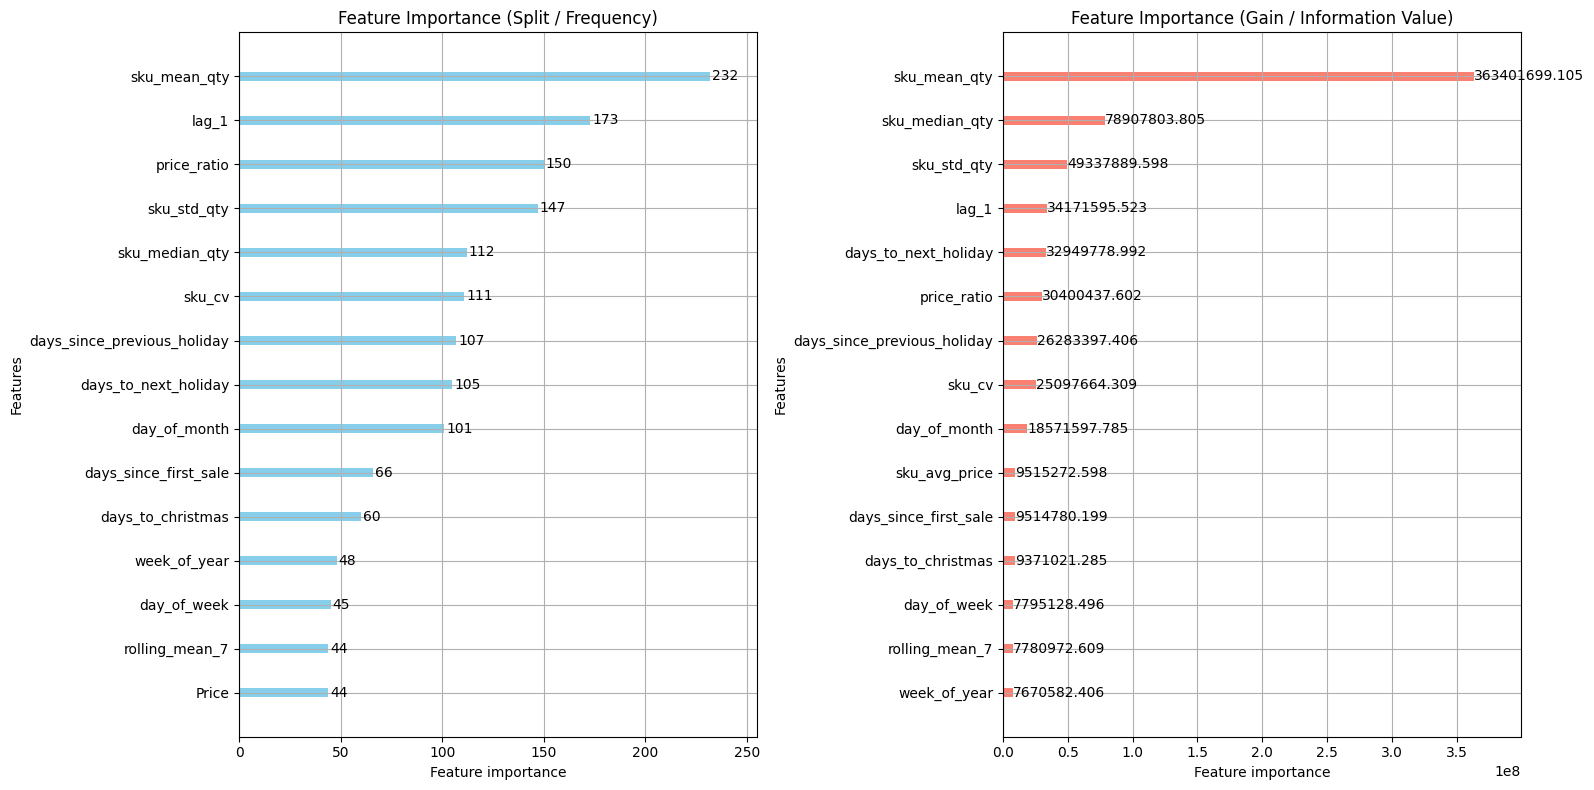

In [36]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


## Loss Function Adjustment

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [37]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.01,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 3085, number of used features: 33
[LightGBM] [Info] Start training from score 5.641052
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[209]	valid_0's rmse: 141.631


Eval metrics


{'MAE': 82.15536538258648,
 'RMSE': 141.6312760486511,
 'wmape_sklearn': np.float64(0.30297894305161427),
 'WMAPE': np.float64(0.3029789430516143)}

Tweedie performed worse than regression

In [38]:
# Update training parameters to handle outliers better
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 167.555


In [39]:
# make predictions
predictions = model.predict(X_test)
evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 115.55578596363199,
 'RMSE': 167.5552031987135,
 'wmape_sklearn': np.float64(0.4261556105522556),
 'WMAPE': np.float64(0.42615561055225565)}

Adjusting objective to Huber loss got even much worse than both regression and tweedie

## Log Transform Target

In [40]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [41]:

# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[223]	valid_0's rmse: 316.948


Eval metrics


{'MAE': 79.32509238936203,
 'RMSE': 142.5120090479523,
 'wmape_sklearn': np.float64(0.29254124228744205),
 'WMAPE': np.float64(0.29254124228744205)}

Log transforming the target did not change weighted MAPE, slightly reduced MAE from 81 to 79 but resulted in higher RMSE of 142.5 compared to previously 139.6

### Plot feature importance again

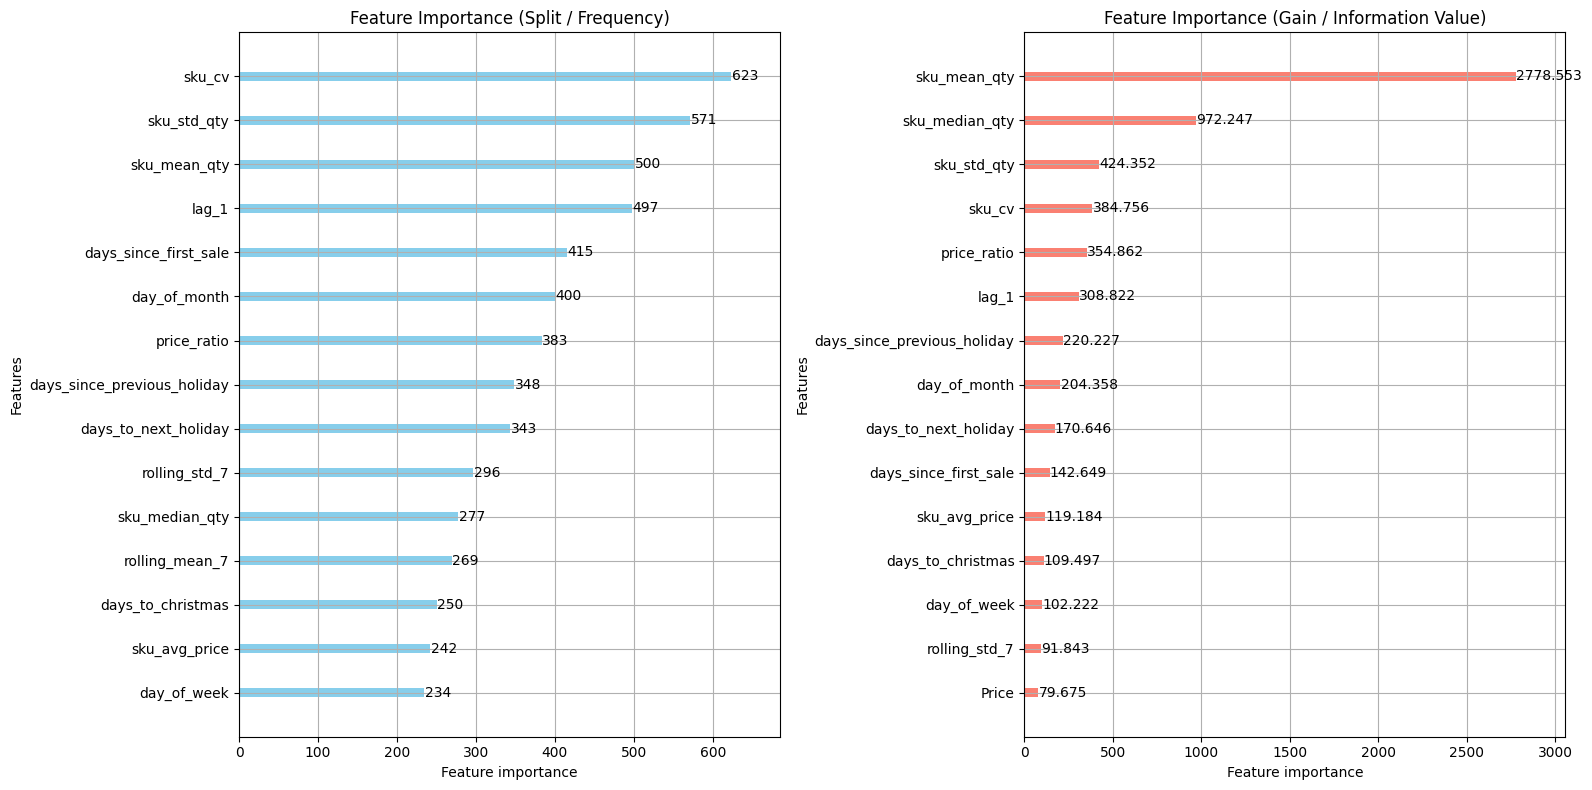

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


### Top 10 features for split

1. SKU coefficient of variation (623)
2. SKU std quantity (571)
3. SKU mean quantity (500)
4. Lag 1
5. Day since first sale
6. Day of month 
7. Price ratio
8. Days since previous holiday 
9. Days to next holiday
10. Rolling std 7 


### Top 10 features for gain

1. SKU mean quantity (2,778)
2. SKU median quantity (972)
3. SKU std quantity (424)
4. SKU coefficient of variation (384)
5. Price ratio (354)
6. Lag1 (308)
7. Day since previous holiday (220)
8. Day of month (204)
9. Day to next holiday (170)
10. Day since first sale (142)


In [43]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

     InvoiceDate StockCode  actual_demand  predicted_demand
3085  2010-10-01     10002            400        279.459801
3086  2010-10-01     11001            240        283.742920
3087  2010-10-01     20724            200        265.495880
3088  2010-10-01     20829            200        274.645609
3089  2010-10-01     20972            500        269.035992


In [44]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for Core-Wholesale segment: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for Core-Wholesale segment: 9.51%


- Aggregating data from daily to weekly dropped the **WMAPE from 29.2% down to 9.5%**. 
- For an online retailer, a 9.5% weekly WMAPE is a solid, operationally viable baseline. 
- It shifts the model's performance rating from poor to good.

### Why the Error Dropped So Drastically

**Day-of-Week Noise Self-Corrects:** 

Daily e-commerce sales fluctuate heavily (e.g., lower sales on Fridays, spikes on Mondays). When you pool these days into a 7-day bucket, the random daily timing variations cancel each other out. 

**Intraday Shipping and Order Latency Erasure:** 

Web traffic and processing delays frequently shift a Monday night order to a Tuesday morning fulfillment. Weekly aggregation completely erases this timing noise.

### Recommendations

**Supply Chain & Inventory (Use Weekly):** A 9.5% error rate is accurate enough to drive bulk inventory purchasing, warehouse space allocation, and vendor purchase orders. 

**Labor & Daily Ops (Do Not Use Daily):** The daily metrics proved the model is too unstable for scheduling day-to-day warehouse picking shifts or managing real-time server scaling. 

### Next Steps
- Run a quick bias check to see if the weekly numbers consistently over-forecast or under-forecast
- Look at a breakdown by product category to see what is driving that remaining 25% error

In [46]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias: 1.10%
Alt result: 1.10%
